In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r'localized_energy_load.csv')

In [4]:
df.head()

,timestamp,region,temperature_c,humidity_pct,wind_speed_mps,solar_radiation_wm2,population_density,industrial_index,commercial_index,hour,day_of_week,month,weekend_flag,holiday_flag,energy_load_mw
0,2022-01-01 00:00:00,West,31.95,56.24,19.23,598.57,4548.33,84.72,39.41,0,5,1,1,0,699.08
1,2022-01-01 01:00:00,Central,24.14,81.83,19.66,177.20,577.52,52.36,10.31,1,5,1,1,0,424.29
2,2022-01-01 02:00:00,East,20.37,39.29,25.37,545.17,966.36,28.85,48.74,2,5,1,1,0,420.05
3,2022-01-01 03:00:00,Central,20.50,54.54,23.59,935.26,2651.03,22.01,53.43,3,5,1,1,0,527.95
4,2022-01-01 04:00:00,Central,25.57,96.17,7.75,520.22,1821.16,94.73,56.11,4,5,1,1,0,723.53


In [5]:
df.tail()

,timestamp,region,temperature_c,humidity_pct,wind_speed_mps,solar_radiation_wm2,population_density,industrial_index,commercial_index,hour,day_of_week,month,weekend_flag,holiday_flag,energy_load_mw
509995,2054-07-03 07:00:00,South,32.52,42.13,20.99,143.86,5036.87,15.56,90.33,7,4,7,0,1,744.79
509996,2042-12-17 08:00:00,South,11.87,63.98,16.13,643.06,325.85,85.02,32.12,8,2,12,0,0,655.65
509997,2025-05-02 11:00:00,North,30.90,36.80,0.40,847.75,5191.53,79.95,51.69,11,4,5,0,0,753.15
509998,2052-03-08 10:00:00,West,23.30,88.01,4.77,626.31,4237.40,63.09,22.14,10,4,3,0,0,636.78
509999,2058-03-28 11:00:00,Central,25.93,36.50,2.01,53.43,2057.91,95.23,NaN,11,3,3,0,0,760.92


In [6]:
df.shape

(510000, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510000 entries, 0 to 509999
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            510000 non-null  object 
 1   region               510000 non-null  object 
 2   temperature_c        504900 non-null  float64
 3   humidity_pct         504900 non-null  float64
 4   wind_speed_mps       504900 non-null  float64
 5   solar_radiation_wm2  504900 non-null  float64
 6   population_density   510000 non-null  float64
 7   industrial_index     504900 non-null  float64
 8   commercial_index     504900 non-null  float64
 9   hour                 510000 non-null  int64  
 10  day_of_week          510000 non-null  int64  
 11  month                510000 non-null  int64  
 12  weekend_flag         510000 non-null  int64  
 13  holiday_flag         510000 non-null  int64  
 14  energy_load_mw       510000 non-null  float64
dtypes: float64(8), in

In [8]:
df.describe()

,temperature_c,humidity_pct,wind_speed_mps,solar_radiation_wm2,population_density,industrial_index,commercial_index,hour,day_of_week,month,weekend_flag,holiday_flag,energy_load_mw
count,504900.000000,504900.000000,504900.000000,504900.000000,510000.000000,504900.000000,504900.000000,510000.000000,510000.000000,510000.000000,510000.000000,510000.000000,510000.000000
mean,27.989392,56.556545,14.977819,550.066424,3051.151979,54.968045,55.042482,11.500863,2.999855,6.520073,0.285696,0.070059,666.902915
std,7.004417,23.985870,8.656068,317.515946,1703.251553,25.983835,25.977651,6.921740,1.999994,3.451082,0.451746,0.255246,110.588964
min,0.000000,15.000000,0.000000,0.000000,100.010000,10.000000,10.000000,0.000000,0.000000,1.000000,0.000000,0.000000,245.240000
25%,23.260000,35.750000,7.470000,275.240000,1577.397500,32.460000,32.530000,6.000000,1.000000,4.000000,0.000000,0.000000,589.500000
50%,27.990000,56.590000,14.980000,550.060000,3052.700000,54.955000,55.060000,12.000000,3.000000,7.000000,0.000000,0.000000,666.340000
75%,32.730000,77.340000,22.460000,824.880000,4528.045000,77.490000,77.550000,18.000000,5.000000,10.000000,1.000000,0.000000,743.450000
max,48.000000,98.000000,30.000000,1100.000000,6000.000000,100.000000,100.000000,23.000000,6.000000,12.000000,1.000000,1.000000,1081.480000


In [9]:
df.duplicated().sum()

np.int64(8858)

In [10]:
df = df.drop_duplicates(keep='first')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

timestamp                 0
region                    0
temperature_c          5100
humidity_pct           5100
wind_speed_mps         5098
solar_radiation_wm2    5100
population_density        0
industrial_index       5100
commercial_index       5096
hour                      0
day_of_week               0
month                     0
weekend_flag              0
holiday_flag              0
energy_load_mw            0
dtype: int64

In [13]:
for col in df.select_dtypes('float64','int64').columns:
    df[col] = df[col].fillna(df[col].median())

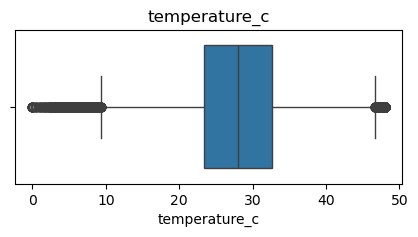

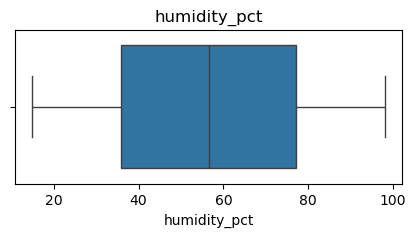

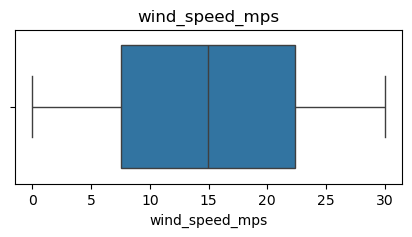

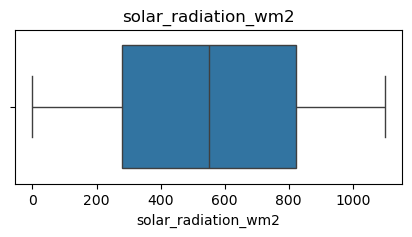

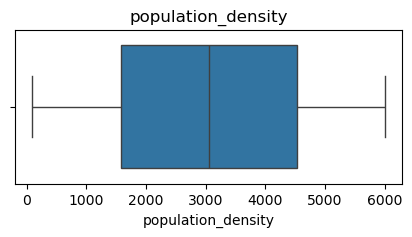

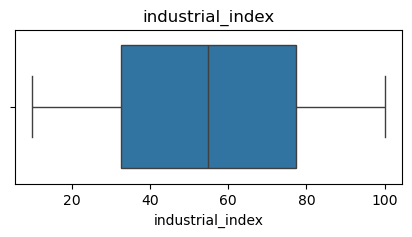

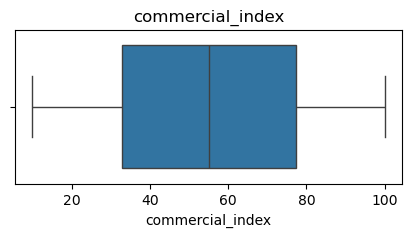

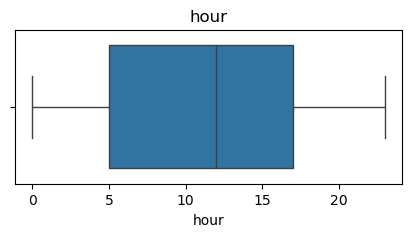

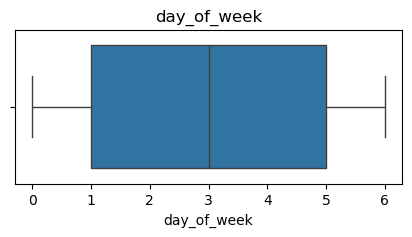

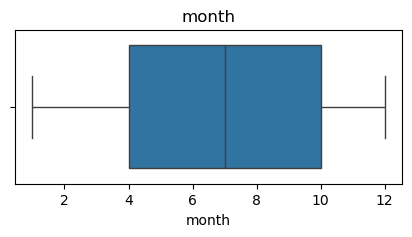

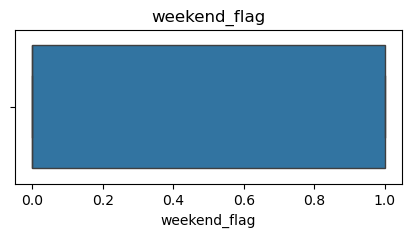

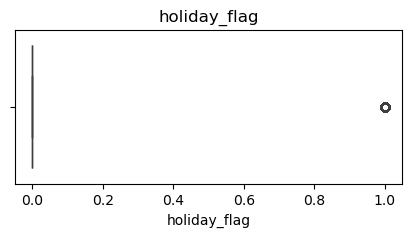

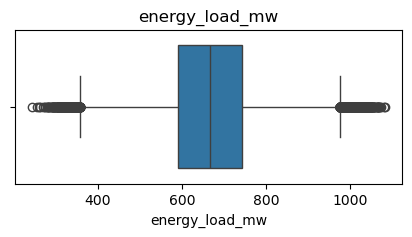

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Text(0.5, 1.0, 'Distribution of Energy Load (MW)')

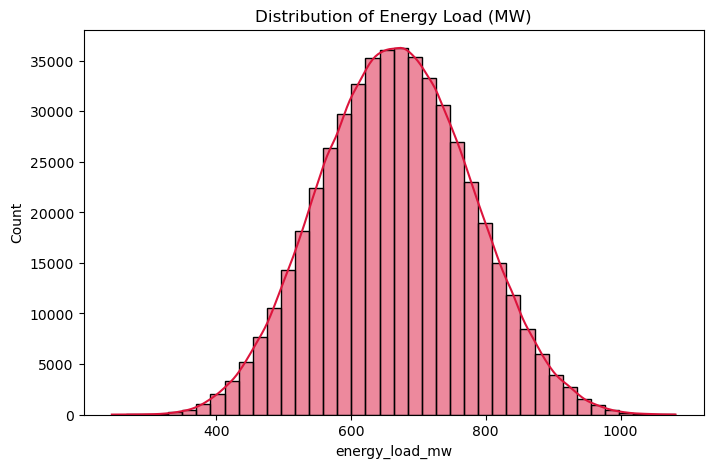

In [15]:
# Target Variable Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df['energy_load_mw'], kde=True, color='crimson', bins=40)
plt.title("Distribution of Energy Load (MW)")

In [16]:
# Temperature vs Energy Load (Scatter with Trend)

# plt.figure(figsize=(8, 5))
# sns.sample(df, n=min(2000, len(df))).plot(kind='scatter', x='temperature_c', y='energy_load_mw', alpha=0.4, color='teal')
# plt.title("Temperature vs Energy Load (Sampled)")

Text(0.5, 1.0, 'Energy Load Distribution Across Regions')

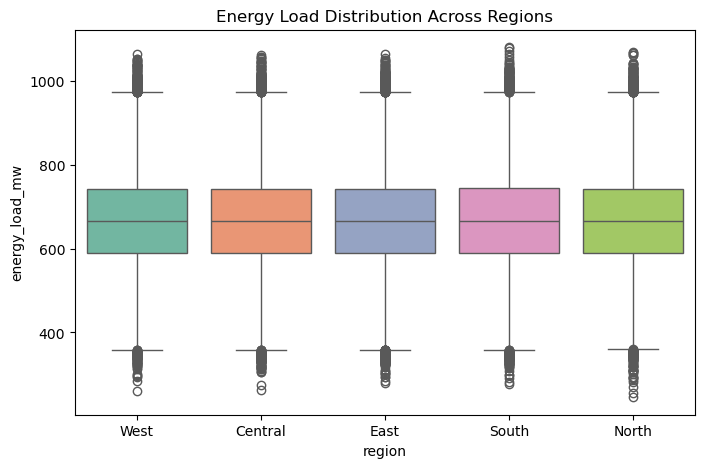

In [17]:
# Energy Load by Region (Boxplot)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='energy_load_mw', palette='Set2')
plt.title("Energy Load Distribution Across Regions")

Text(0.5, 1.0, 'Average Hourly Energy Load: Weekday vs Weekend')

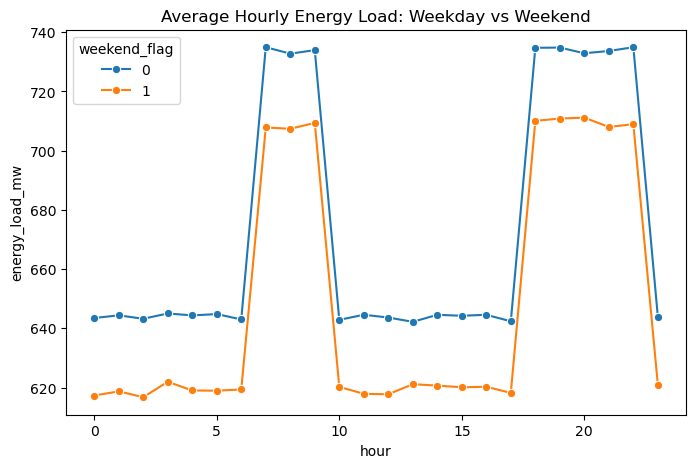

In [18]:
# Hourly Profile of Energy Load by Weekend Flag

plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='hour', y='energy_load_mw', hue='weekend_flag', errorbar=None, marker='o')
plt.title("Average Hourly Energy Load: Weekday vs Weekend")

Text(0.5, 1.0, 'Monthly Seasonal Trends by Region')

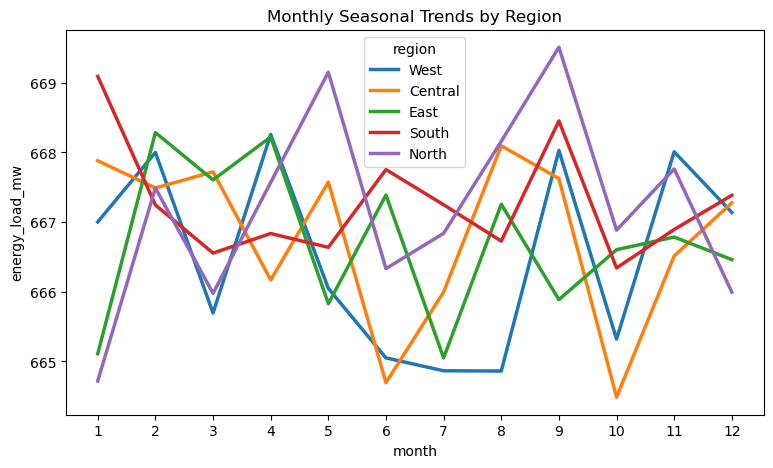

In [19]:
# Monthly Profile of Energy Load across Regions

plt.figure(figsize=(9, 5))
sns.lineplot(data=df, x='month', y='energy_load_mw', hue='region', errorbar=None, linewidth=2.5)
plt.xticks(range(1, 13))
plt.title("Monthly Seasonal Trends by Region")

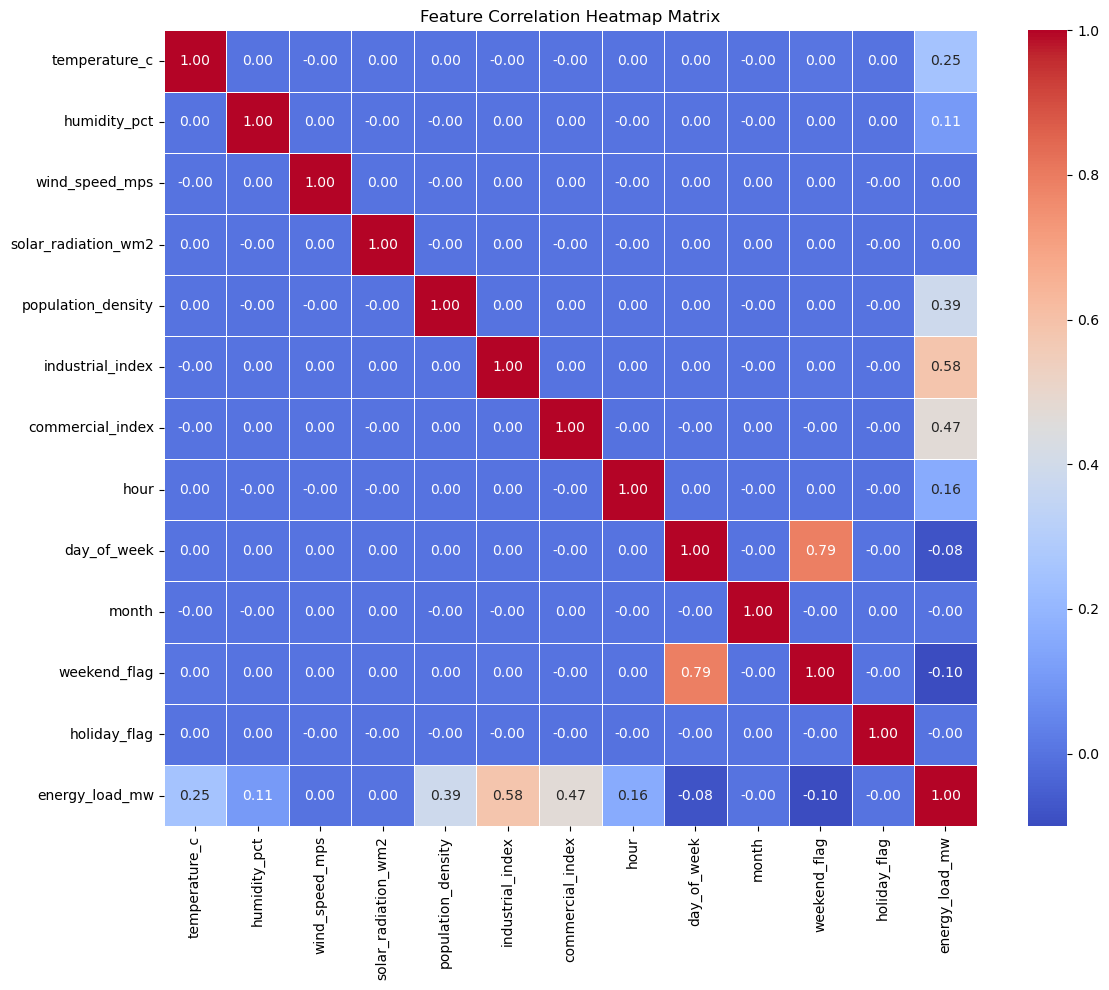

In [20]:
# Correlation Heatmap of Numeric Features

plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap Matrix")
plt.tight_layout()

Text(0.5, 1.0, 'Industrial Activity Index vs Energy Load')

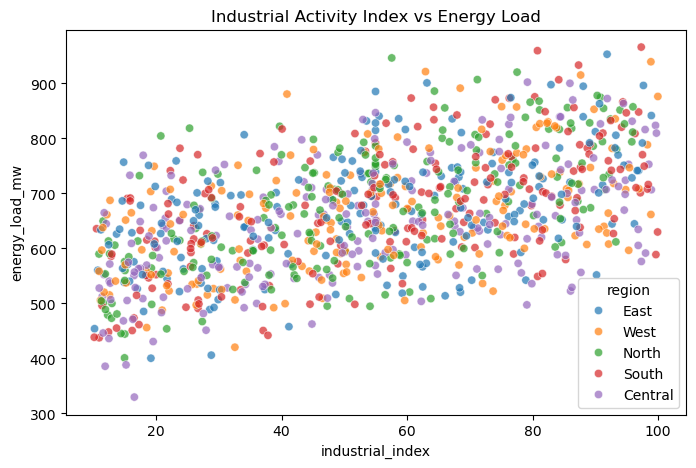

In [21]:
# Industrial Index vs Energy Load Matrix

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(min(1000, len(df))), x='industrial_index', y='energy_load_mw', hue='region', alpha=0.7)
plt.title("Industrial Activity Index vs Energy Load")

Text(0.5, 1.0, 'Commercial Activity Index vs Energy Load')

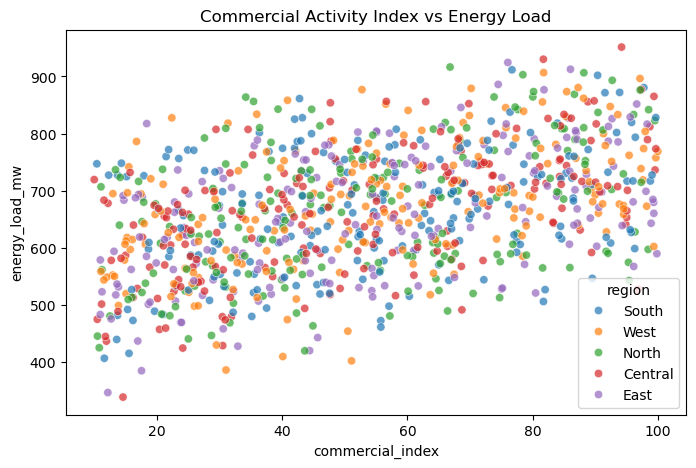

In [22]:
# Commercial Index vs Energy Load Matrix

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(min(1000, len(df))), x='commercial_index', y='energy_load_mw', hue='region', alpha=0.7)
plt.title("Commercial Activity Index vs Energy Load")

In [23]:
# Humidity vs Energy Load

# plt.figure(figsize=(8, 5))
# sns.hexbin(data=df, x='humidity_pct', y='energy_load_mw', gridsize=25, cmap='Blues')
# plt.title("Density Analysis: Humidity vs Energy Load")
# plt.colorbar(label='Count')

Text(0.5, 1.0, 'Wind Speed Regression Trend Line')

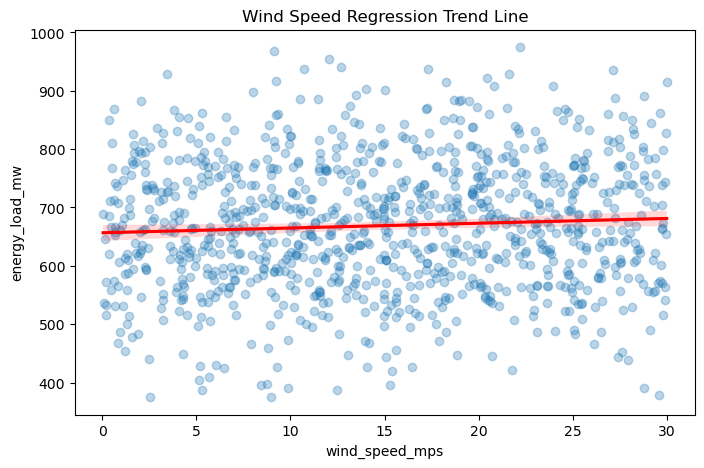

In [24]:
# Wind Speed vs Energy Load

plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(min(1000, len(df))), x='wind_speed_mps', y='energy_load_mw', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Wind Speed Regression Trend Line")

In [25]:
# Distribution of engineered feature 'temp_humidity_index' by Holiday Flag

# plt.figure(figsize=(8, 5))
# sns.kdeplot(data=df, x='temp_humidity_index', hue='holiday_flag', fill=True, common_norm=False, palette='mako')
# plt.title("Engineered Temp-Humidity Index Distribution")

Text(0.5, 1.0, ' Holiday Load Reductions across Diurnal Cycles')

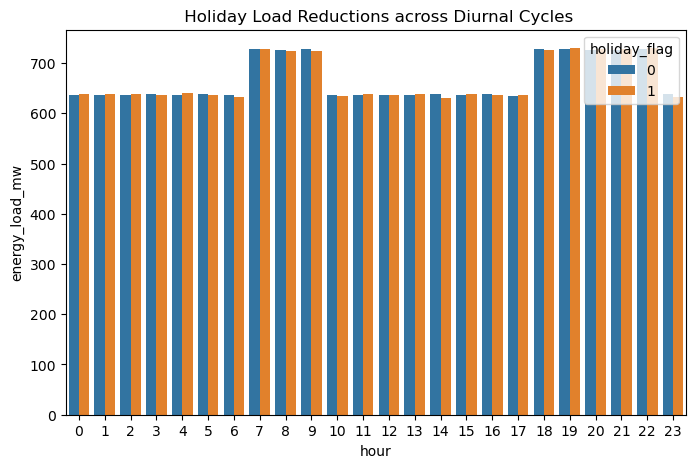

In [26]:
# Holiday Impact on Energy Demand by Hour

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='hour', y='energy_load_mw', hue='holiday_flag', errorbar=None)
plt.title(" Holiday Load Reductions across Diurnal Cycles")

In [27]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [28]:
# Sample 1,00,000 rows for efficient KNN execution

df_sample = df.sample(n=100000, random_state=42).reset_index(drop=True)

In [29]:
# Separate independent features (X) and target variable (y)

x = df_sample.drop(columns=['timestamp', 'energy_load_mw'])
y = df_sample['energy_load_mw']

In [30]:
# Encoding Categorical and Feature using (One-hot encoder)

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
region_encoded = encoder.fit_transform(x[['region']])

# Convert encoded arrays into a DataFrame with proper column names
region_df = pd.DataFrame(region_encoded, columns=encoder.get_feature_names_out(['region']))

# Drop the original 'region' text column and concatenate the new binary columns
x_processed = x.drop(columns=['region']).reset_index(drop=True)
x_processed = pd.concat([x_processed, region_df], axis=1)

In [31]:
K = range(1, 20, 2)
for i in K:
    x_train, x_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, random_state=42)
    
    #
    scaler = StandardScaler()
    
    # Fit only on the training set and transform both sets
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    #
    # Initialize the regressor with k=5 neighbors
    knn = KNeighborsRegressor(n_neighbors=i)
    
    # Train the model
    knn.fit(x_train_scaled, y_train)
    
    # Generate predictions on the test set
    y_pred = knn.predict(x_test_scaled)

    # Evaluation matrix
    r2_lr = r2_score(y_test, y_pred)
    mae_lr = mean_absolute_error(y_test, y_pred)
    mse_lr = mean_squared_error(y_test, y_pred)
    rmse_lr = root_mean_squared_error(y_test, y_pred)
    mape_lr = mean_absolute_percentage_error(y_test, y_pred)

    print(f" K value : {i} ")
    print(f" R² Score : {r2_lr*100}")
    print(f" MAE : {mae_lr}")
    print(f" MSE : {mse_lr}")
    print(f" RMSE : {rmse_lr}")
    print(f" MAPE : {mape_lr*100}")
    print()

 K value : 1 
 R² Score : 52.598964939748306
 MAE : 60.29590700000001
 MSE : 5797.253921090001
 RMSE : 76.13970003283438
 MAPE : 9.28252657270843

 K value : 3 
 R² Score : 70.29609062293729
 MAE : 47.9745385
 MSE : 3632.8553772927776
 RMSE : 60.27317294860772
 MAPE : 7.391460583413048

 K value : 5 
 R² Score : 73.70049635870404
 MAE : 45.4116915
 MSE : 3216.488846993
 RMSE : 56.71409742729757
 MAPE : 7.010918222966427

 K value : 7 
 R² Score : 74.943346421366
 MAE : 44.338729428571426
 MSE : 3064.485470063878
 RMSE : 55.357795025306764
 MAPE : 6.852381389246311

 K value : 9 
 R² Score : 75.52866802766553
 MAE : 43.86019933333333
 MSE : 2992.8993122319753
 RMSE : 54.70739723503555
 MAPE : 6.787017400719334

 K value : 11 
 R² Score : 75.76188209726023
 MAE : 43.66144895454545
 MSE : 2964.376703438884
 RMSE : 54.446089882000564
 MAPE : 6.7615638989757425

 K value : 13 
 R² Score : 75.86195914355498
 MAE : 43.61235773076923
 MSE : 2952.1370540661246
 RMSE : 54.33357207165865
 MAPE : 

Text(0.5, 1.0, 'Model Predictions vs. Actual Energy Load')

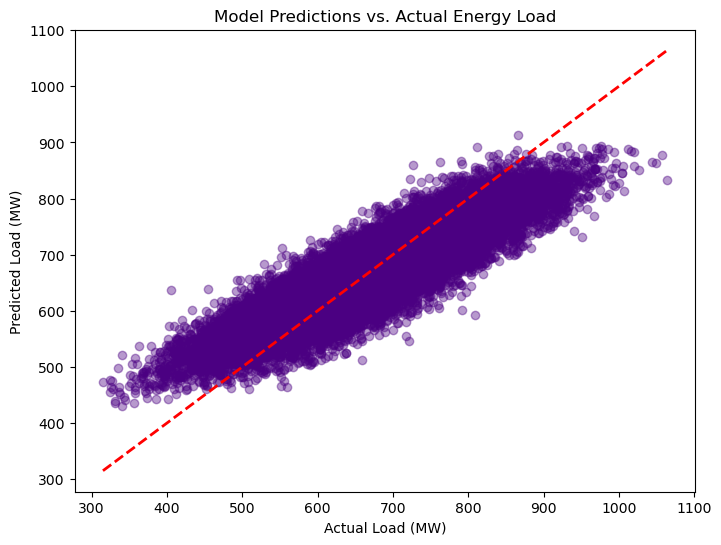

In [32]:
# Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Load (MW)')
plt.ylabel('Predicted Load (MW)')
plt.title("Model Predictions vs. Actual Energy Load")

Text(0.5, 1.0, 'Model Residuals Error Distribution')

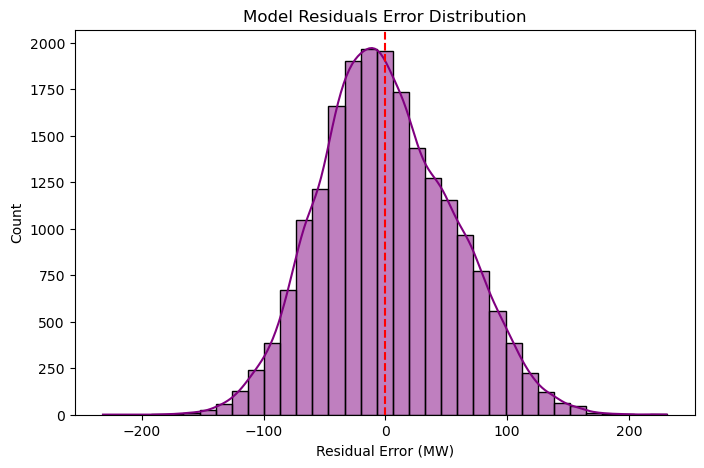

In [33]:
# Residuals Distribution

residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=35)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual Error (MW)')
plt.title("Model Residuals Error Distribution")

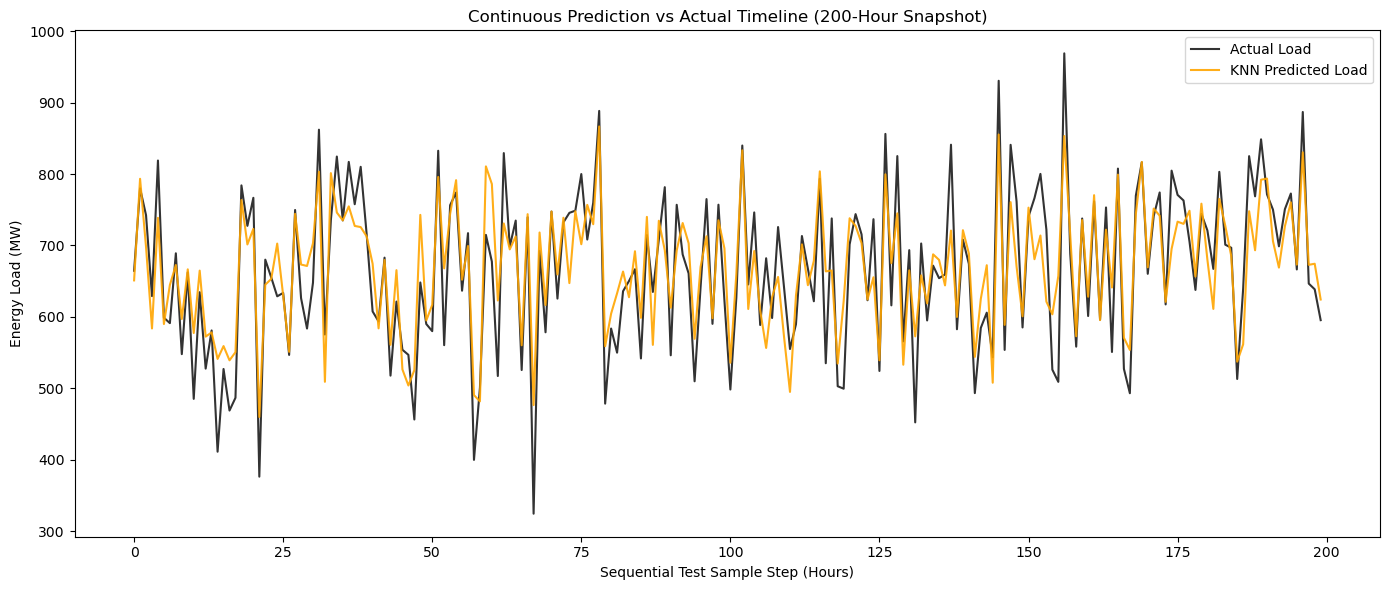

In [34]:
# Timeline view of Predictions vs Actual (Sampled window for clarity)

plt.figure(figsize=(14, 6))
eval_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).iloc[:200]  # First 200 hours
plt.plot(eval_df['Actual'].values, label='Actual Load', color='black', alpha=0.8, lw=1.5)
plt.plot(eval_df['Predicted'].values, label='KNN Predicted Load', color='orange', alpha=0.9, lw=1.5)
plt.ylabel('Energy Load (MW)')
plt.xlabel('Sequential Test Sample Step (Hours)')
plt.title("Continuous Prediction vs Actual Timeline (200-Hour Snapshot)")
plt.legend()
plt.tight_layout()